# Plot hFF from makeRatioBinned3D output
Plots `hFF_0_q_x` histograms.  
- **`fixed_x`** : one figure per xB bin, all Q2 bins overlaid  
- **`fixed_q`** : one figure per Q2 bin, all xB bins overlaid  
- **`fixed_xq`**: one figure per xB bin, subpanel per Q2 bin, VARs overlaid

In [1297]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

In [1298]:
# ── Configuration ────────────────────────────────────────────────────────────
IN_FILE  = "../histograms/final_note/ratios_gen_cuts_no_match_pT.root"#gen.root"
OUT_DIR  = None   # e.g. "ff_plots" — None = display inline

# Plot mode
# 'fixed_x'  : one figure per xB bin,  Q2 bins overlaid as curves
# 'fixed_q'  : one figure per Q2 bin,  xB bins overlaid as curves
# 'fixed_xq' : one figure per xB bin,  subpanel per Q2 bin, VARs overlaid
MODE = 'fixed_xq'

# VAR overlay — list of var indices (0-based) to overlay on each panel.
# Single entry behaves identically to the old scalar VAR setting.
# e.g. VARS = [5] or VARS = [0, 1, 2, 5]
VARS       = [0,1,2,3]#,4,5,6,7]
#VAR_LABELS = {0: r'$0 < p_T < 0.3$', 1: r'$0.3 < p_T < 0.6$', 2: r'$0.6 < p_T < 0.9$',  3: r'$0.9 < p_T < 1.2$'}  # shown in legend when len(VARS) > 1
#VAR_LABELS = {0: r'$1.7 < M_X < 2.0$', 1: r'$2.0 < M_X < 2.3$', 2: r'$2.3 < M_X < 2.6$',3: r'$2.6 < M_X < 2.9$',4:'',5:'',6:''}  # shown in legend when len(VARS) > 1
VAR_LABELS = {0: r'$0$', 1: r'$1$', 2: r'$2$',3: r'$3$',4:'4',5:'5'}  # shown in legend when len(VARS) > 1


# Kinematic bin definitions — must match cut_values.h
BINS_Q2 = 12;  Q2_MIN, Q2_MAX = 2.0, 8.0
BINS_XB = 14;  XB_MIN, XB_MAX = 0.1, 0.66
BINS_Z  = 14

hist = 'DuM'
yMax = .7

In [1299]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def ff_theory(z):
    """Leading-order FF baseline (1-z)/(1+z)."""
    return (1 - z) / (1 + z)

def load_hFF(f, var, q, x):
    """Return (values, errors, centers) for hFF_{var}_{q+1}_{x+1}, or None."""
    name = f"h{hist}_0_{q+1}_{x+1}_v{var}" #{var}_
    key  = name + ";1" if (name + ";1") in f else name
    if key not in f:
        return None
    h = f[key]
    edges   = h.axis().edges()
    centers = (edges[:-1] + edges[1:]) / 2
    return np.array(h.values()), np.array(h.errors()), centers

def q2_label(q):
    lo = Q2_MIN + q * (Q2_MAX - Q2_MIN) / BINS_Q2
    hi = Q2_MIN + (q + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
    return rf"${lo:.1f} < Q^2 < {hi:.1f}\;\mathrm{{GeV}}^2$"

def xb_label(x):
    lo = XB_MIN + x * (XB_MAX - XB_MIN) / BINS_XB
    hi = XB_MIN + (x + 1) * (XB_MAX - XB_MIN) / BINS_XB
    return rf"${lo:.2f} < x_B < {hi:.2f}$"

In [1300]:
# ── JAM20 SIDIS curves ────────────────────────────────────────────────────────
import pandas as pd

JAM20_CSV = "../data/exp_data/jam20sidis_ratio_lowQ.csv"

try:
    _jam = pd.read_csv(JAM20_CSV)
    _jam_q2_vals = [2, 3, 4, 5, 6]

    def _q2_to_bin(q2_val):
        return min(int((q2_val - Q2_MIN) / (Q2_MAX - Q2_MIN) * BINS_Q2), BINS_Q2 - 1)

    JAM20_BINS = {
        _q2_to_bin(q2): {
            'z':    _jam['z'].values,
            'mean': _jam[f'mean_Q2={q2}'].values,
            'lo':   _jam[f'lo16_Q2={q2}'].values,
            'hi':   _jam[f'hi84_Q2={q2}'].values,
            'q2':   q2,
        }
        for q2 in _jam_q2_vals
    }
    print(f"Loaded JAM20 SIDIS curves for Q2 = {_jam_q2_vals}")
    print(f"  -> notebook Q2 bins: { {q2: _q2_to_bin(q2) for q2 in _jam_q2_vals} }")
except FileNotFoundError:
    JAM20_BINS = {}
    print(f"JAM20 CSV not found at {JAM20_CSV} — skipping overlay")

Loaded JAM20 SIDIS curves for Q2 = [2, 3, 4, 5, 6]
  -> notebook Q2 bins: {2: 0, 3: 2, 4: 4, 5: 6, 6: 8}


In [1301]:
# ── Load file ─────────────────────────────────────────────────────────────────
inFile = uproot.open(IN_FILE)

# Sanity check using first VAR
sample = load_hFF(inFile, VARS[0], 0, 0)
if sample is None:
    raise RuntimeError(f"No h{hist}_{VARS[0]}_1_1 found in {IN_FILE}. Check IN_FILE and VARS.")
print(f"Loaded {IN_FILE}")
print(f"z bins: {len(sample[2])},  z range: [{sample[2][0]:.2f}, {sample[2][-1]:.2f}]")
print(f"VAR overlay: {VARS}")

RuntimeError: No hDuM_0_1_1 found in ../histograms/final_note/ratios_gen_cuts_no_match_pT.root. Check IN_FILE and VARS.

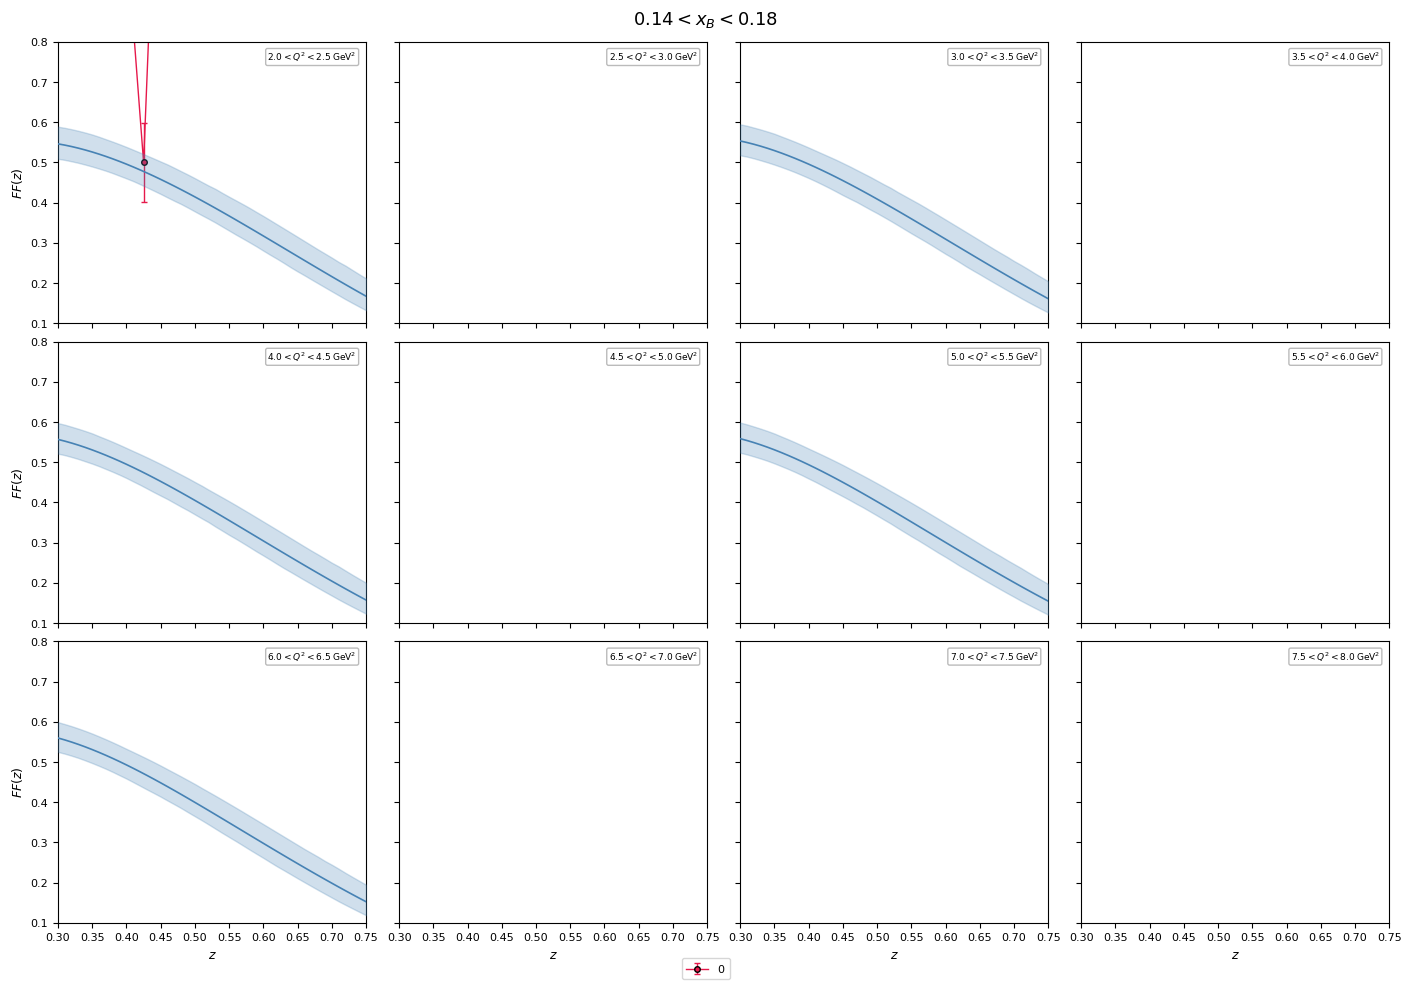

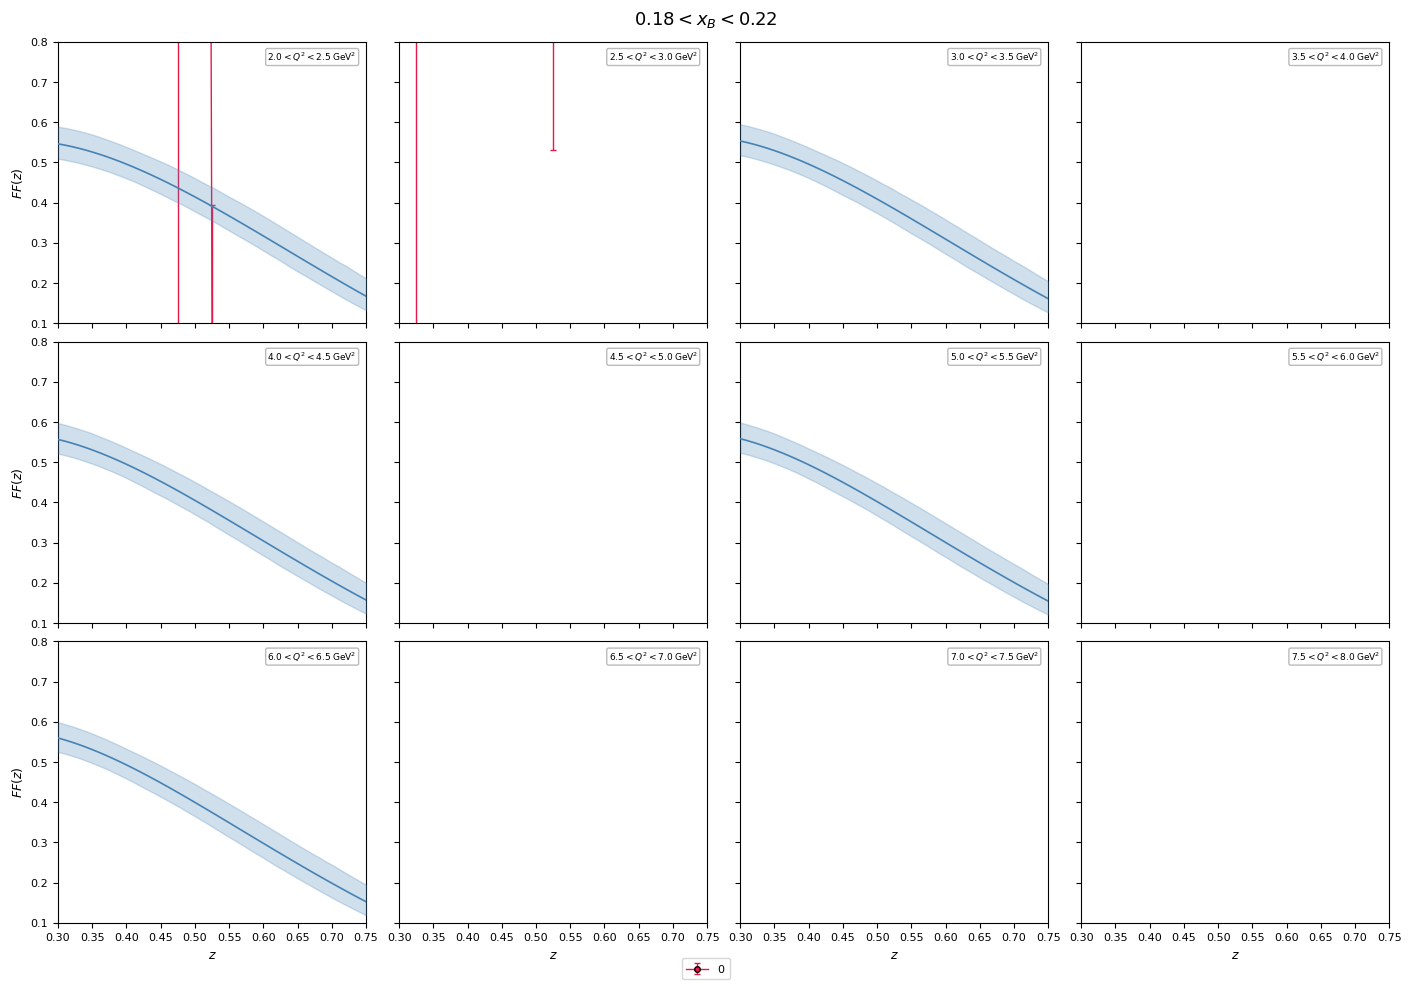

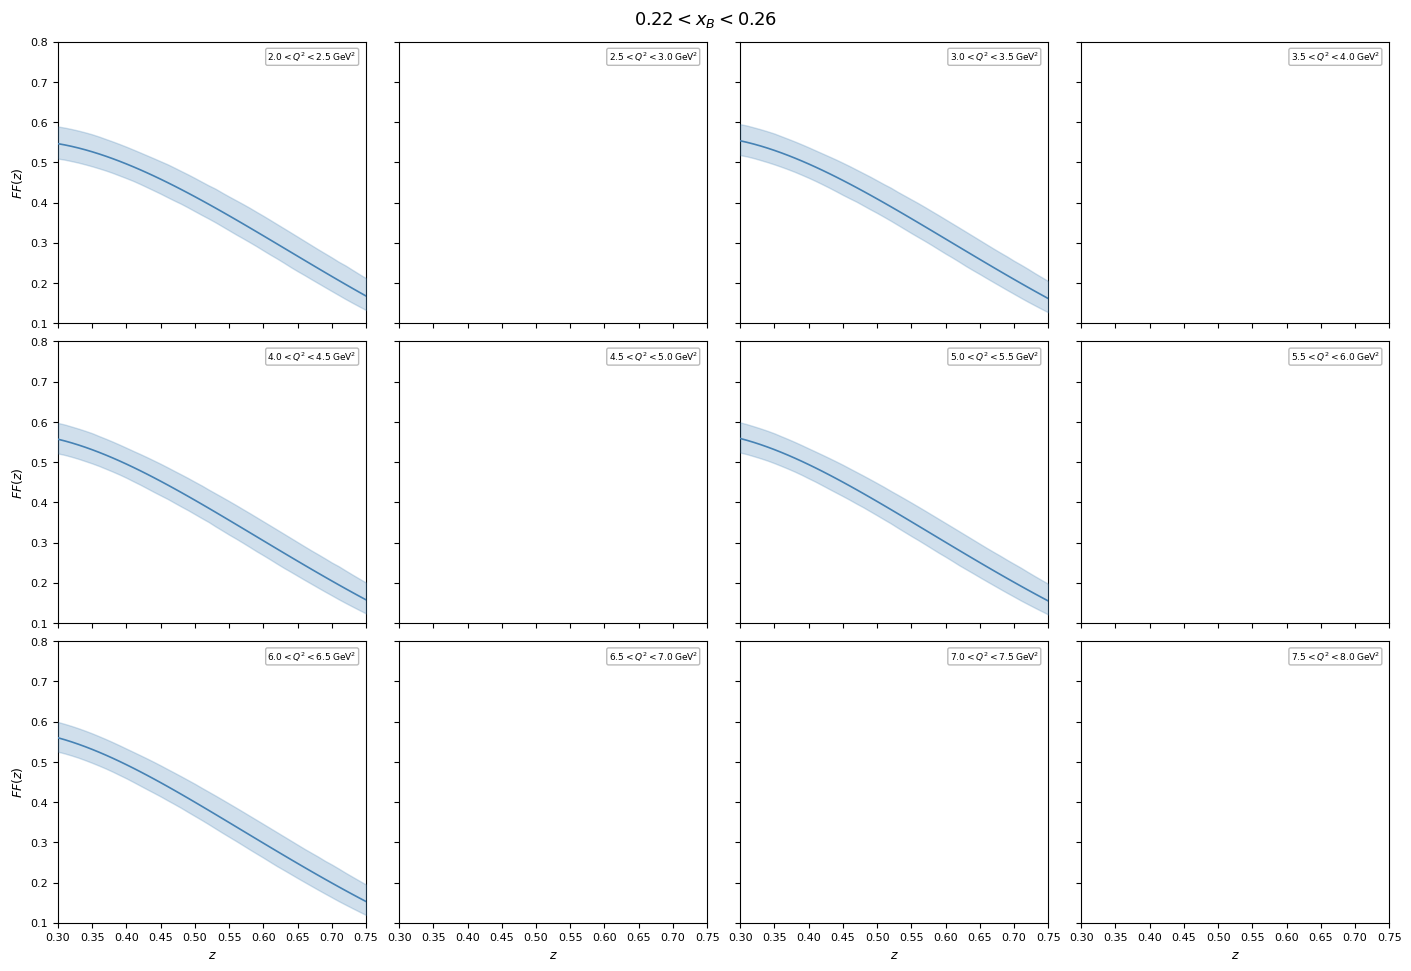

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

colors_list = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#469990','#dcbeff',
    '#9a6324','#800000','#aaffc3','#a9a9a9'
]
var_palettes = [
    ['#e6194b','#ff7f7f','#c00000','#800000'],
    ['#4363d8','#7fbfff','#0000c0','#000080'],
    ['#3cb44b','#7fff7f','#008000','#004000'],
    ['#f58231','#ffc07f','#c06000','#804000'],
    ['#911eb4','#df7fff','#600080','#400060'],
    ['#42d4f4','#7fffff','#0080c0','#004060'],
]
markers    = ['o','s','^','D','v','<','>','p','h','P','X','*','d','H']
linestyles = ['-', '--', ':', '-.']
z_line     = np.linspace(0.3, 1.0, 500)
multi_var  = len(VARS) > 1

# ── fixed_xq : one figure per xB bin, grid of Q2 subpanels, VARs overlaid ────
if MODE == 'fixed_xq':
    NCOLS = 4
    nrows = -(-BINS_Q2 // NCOLS)   # ceiling division

    for ix in range(BINS_XB):
        fig, axs = plt.subplots(
            nrows, NCOLS, figsize=(NCOLS * 3.5, nrows * 3.2),
            sharex=True, sharey=True, layout='constrained'
        )
        fig.suptitle(xb_label(ix), fontsize=13)
        axs_flat = axs.ravel()

        has_data = False
        for iq in range(BINS_Q2):
            ax = axs_flat[iq]
            #ax.plot(z_line, ff_theory(z_line), 'k--', lw=0.8, zorder=0)
            ax.text(0.97, 0.97, q2_label(iq), transform=ax.transAxes,
                    ha='right', va='top', fontsize=6.5,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.8))

            for vi, var in enumerate(VARS):
                result = load_hFF(inFile, var, iq, ix)
                if result is None:
                    continue
                v, e, centers = result
                mask = np.isfinite(v) & (v != 0)
                if not mask.any():
                    continue
                v = np.where(mask, v, np.nan)
                e = np.where(mask, e, np.nan)

                color  = var_palettes[vi % len(var_palettes)][0]
                marker = markers[vi % len(markers)]
                ls     = linestyles[vi % len(linestyles)] if multi_var else ''
                lbl    = VAR_LABELS.get(var, f'Var {var}') if multi_var else None

                ax.errorbar(centers, v, e,
                            marker=marker, color=color, linestyle=ls,
                            capsize=2, lw=1, capthick=1, markersize=4, mec='black',
                            label=lbl)
                has_data = True

            # JAM20 overlay per Q2 subpanel
            if iq in JAM20_BINS:
                jam = JAM20_BINS[iq]
                zm  = (jam['z'] >= 0.3) & (jam['z'] <= 0.75)
                ax.fill_between(jam['z'][zm], jam['lo'][zm], jam['hi'][zm],
                                color='steelblue', alpha=0.25, zorder=3)
                ax.plot(jam['z'][zm], jam['mean'][zm],
                        color='steelblue', lw=1.2, zorder=4)

            ax.set_xlim(0.3, 0.75)
            ax.set_ylim(0.1, .8)
            ax.tick_params(labelsize=8)
            col = iq % NCOLS
            row = iq // NCOLS
            if col == 0:
                ax.set_ylabel(r'$FF(z)$', fontsize=9)
            if row == nrows - 1:
                ax.set_xlabel(r'$z$', fontsize=9)

        for iq in range(BINS_Q2, nrows * NCOLS):
            axs_flat[iq].set_visible(False)

        if multi_var:
            handles, labels = axs_flat[0].get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc='lower center',
                           bbox_to_anchor=(0.5, -0.02), ncol=len(VARS),
                           fontsize=8, frameon=True)

        if not has_data:
            plt.close(fig)
            continue

        if OUT_DIR:
            fname = f"{OUT_DIR}/hFF_fixed_xq_x{ix+1}.png"
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            plt.show()

# ── fixed_x / fixed_q ────────────────────────────────────────────────────────
else:
    if MODE == 'fixed_x':
        n_outer, n_inner = BINS_XB, BINS_Q2
        outer_label = xb_label
        inner_label = q2_label
        def get_indices(outer, inner): return inner, outer
    else:  # fixed_q
        n_outer, n_inner = BINS_Q2, BINS_XB
        outer_label = q2_label
        inner_label = xb_label
        def get_indices(outer, inner): return outer, inner

    z_span  = sample[2][-1] - sample[2][0]
    offsets = np.linspace(-(n_inner-1)/2, (n_inner-1)/2, n_inner) * z_span * 0.003

    for outer in range(n_outer):
        fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
        #(z_line, ff_theory(z_line), 'k--', lw=1, zorder=0, label='Field-Feynman theory')

        has_data = False

        for vi, var in enumerate(VARS):
            palette = var_palettes[vi % len(var_palettes)]

            for inner in range(n_inner):
                q, x   = get_indices(outer, inner)
                result = load_hFF(inFile, var, q, x)
                if result is None:
                    continue
                v, e, centers = result

                mask = np.isfinite(v) & (v != 0)
                if not mask.any():
                    continue
                v = np.where(mask, v, np.nan)
                e = np.where(mask, e, np.nan)

                z_plot = centers + offsets[inner]
                marker = markers[inner % len(markers)]

                if multi_var:
                    color   = palette[inner % len(palette)]
                    ls      = linestyles[vi % len(linestyles)]
                    kin_lbl = inner_label(inner)
                    lbl     = f"{VAR_LABELS.get(var, f'Var {var}')} — {kin_lbl}"
                else:
                    color = colors_list[inner % len(colors_list)]
                    ls    = ''
                    lbl   = inner_label(inner)

                ax.errorbar(z_plot, v, e,
                            marker=marker, color=color, linestyle=ls,
                            capsize=2, lw=1, capthick=1, markersize=5, mec='black',
                            label=lbl)
                has_data = True

        if not has_data:
            plt.close(fig)
            continue

        # JAM20 overlay — in fixed_q each figure maps to one Q2 bin;
        # in fixed_x each figure spans all Q2 inner bins so we add one band per bin
        if MODE == 'fixed_q' and outer in JAM20_BINS:
            jam = JAM20_BINS[outer]
            zm  = (jam['z'] >= 0.3) & (jam['z'] <= 0.75)
            ax.fill_between(jam['z'][zm], jam['lo'][zm], jam['hi'][zm],
                            color='steelblue', alpha=0.25, zorder=3,
                            label=f"JAM20 (68% CI, $\\langle Q^2\\rangle={jam['q2']}$ GeV$^2$)")
            ax.plot(jam['z'][zm], jam['mean'][zm],
                    color='steelblue', lw=1.5, zorder=4)
        elif MODE == 'fixed_x':
            added_jam_label = False
            for inner in range(n_inner):
                q, _ = get_indices(outer, inner)
                if q not in JAM20_BINS:
                    continue
                jam = JAM20_BINS[q]
                zm  = (jam['z'] >= 0.3) & (jam['z'] <= 0.75)
                lbl = f"JAM20 $Q^2={jam['q2']}$" if not added_jam_label else None
                ax.fill_between(jam['z'][zm], jam['lo'][zm], jam['hi'][zm],
                                color=colors_list[inner % len(colors_list)],
                                alpha=0.15, zorder=3)
                ax.plot(jam['z'][zm], jam['mean'][zm],
                        color=colors_list[inner % len(colors_list)],
                        lw=1.2, zorder=4, linestyle='--', label=lbl)
                added_jam_label = True

        ax.set_title(outer_label(outer), fontsize=13)
        ax.set_xlabel(r'$z$', fontsize=13)
        ax.set_ylabel(r'$FF(z) = (4-R)/(4R-1)$', fontsize=13)
        ax.set_xlim(0.3, 0.75)
        ax.set_ylim(0.1, yMax)
        ax.tick_params(labelsize=11)
        ax.legend(fontsize=7, loc='upper right', ncol=2 if not multi_var else max(1, len(VARS)))

        if OUT_DIR:
            fname = f"{OUT_DIR}/hFF_{MODE}_{outer+1}.png"
            fig.savefig(fname, dpi=150)
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            plt.show()

In [ ]:
# ── Export CSV ───────────────────────────────────────────────────────────────
import csv

CSV_OUT = "hFF_data.csv"

with open(CSV_OUT, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["var", "q_bin", "x_bin", "q2_lo", "q2_hi", "xb_lo", "xb_hi",
                     "z_center", "ff_value", "ff_error"])

    for var in VARS:
        for q in range(BINS_Q2):
            q2_lo = Q2_MIN + q       * (Q2_MAX - Q2_MIN) / BINS_Q2
            q2_hi = Q2_MIN + (q + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
            for x in range(BINS_XB):
                xb_lo = XB_MIN + x       * (XB_MAX - XB_MIN) / BINS_XB
                xb_hi = XB_MIN + (x + 1) * (XB_MAX - XB_MIN) / BINS_XB
                result = load_hFF(inFile, var, q, x)
                if result is None:
                    continue
                v, e, centers = result
                for z_c, ff_v, ff_e in zip(centers, v, e):
                    if np.isfinite(ff_v) and ff_v != 0:
                        writer.writerow([var, q + 1, x + 1,
                                         f"{q2_lo:.3f}", f"{q2_hi:.3f}",
                                         f"{xb_lo:.4f}", f"{xb_hi:.4f}",
                                         f"{z_c:.4f}", f"{ff_v:.6f}", f"{ff_e:.6f}"])

print(f"Wrote {CSV_OUT}")

Wrote hFF_data.csv
